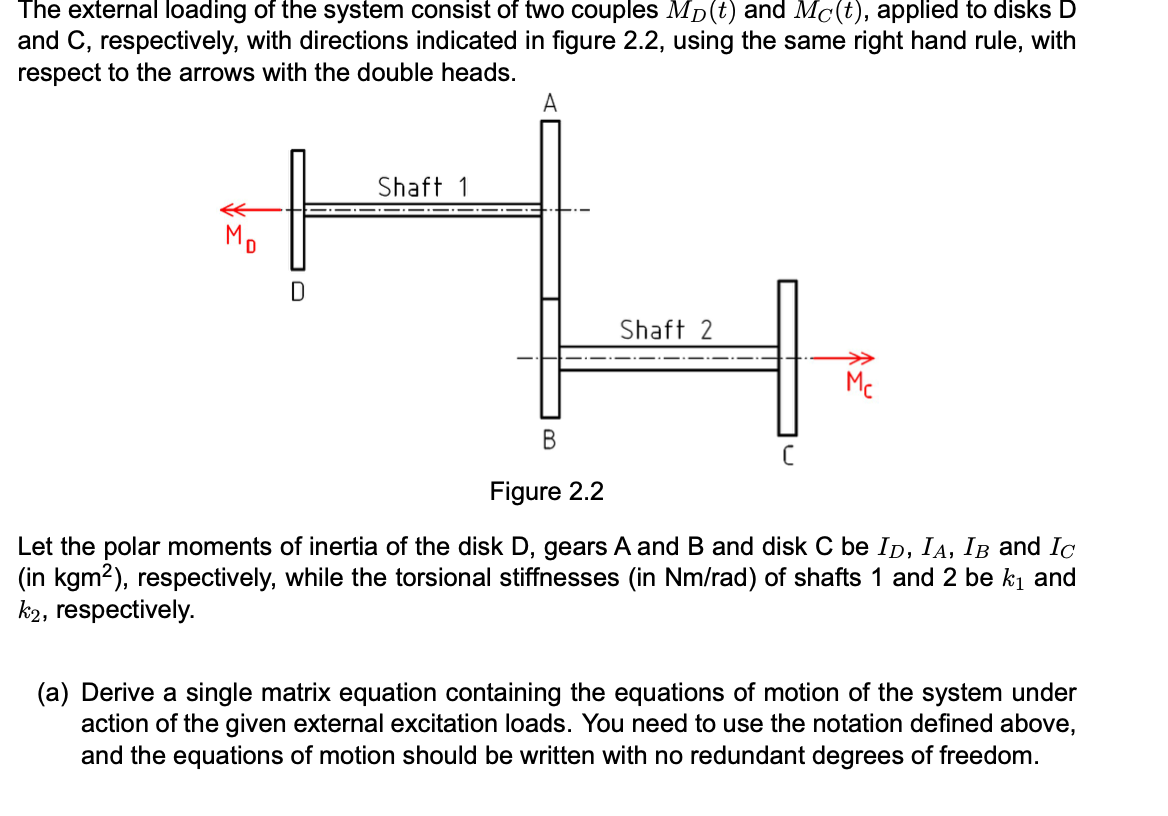

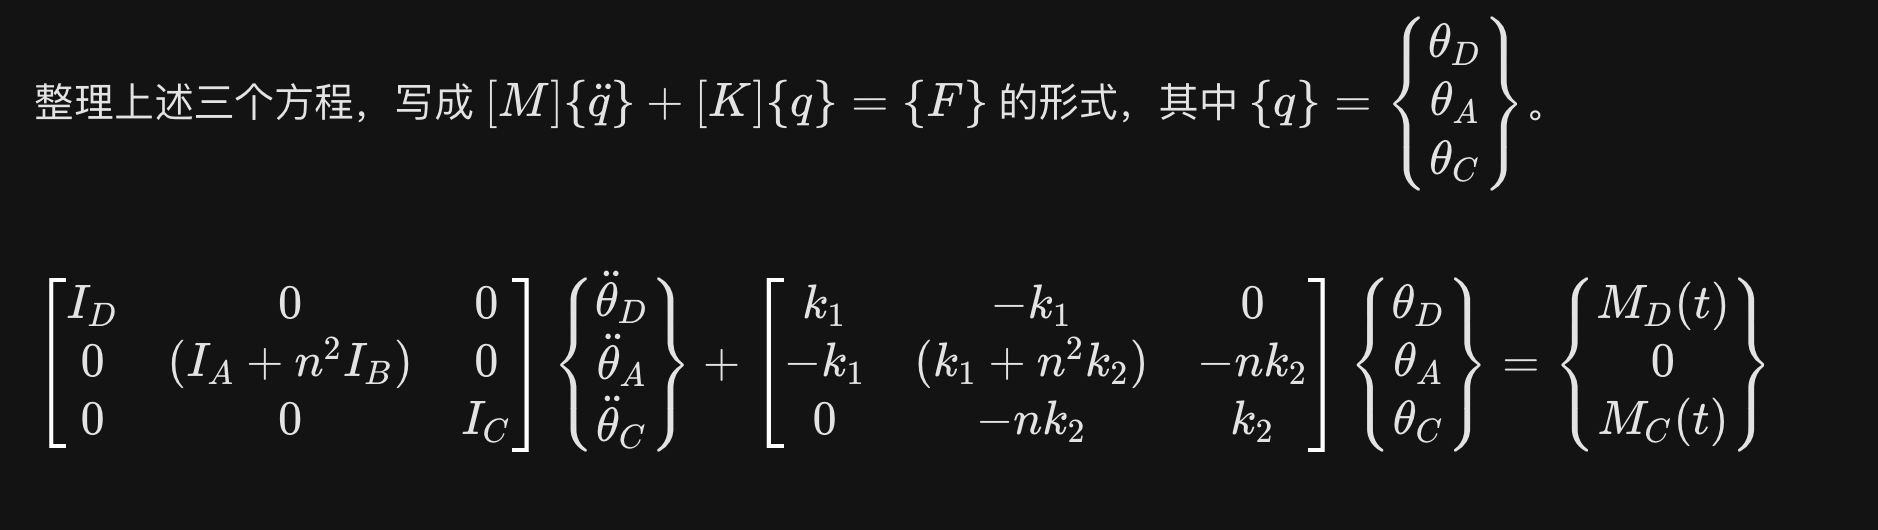

In [7]:
import numpy as np
from numpy.linalg import eig, inv

def solve_vibration_exam(M, C, K, F_vector, target_freq_hz=None):
    """
    M, C, K: 质量、阻尼、刚度矩阵
    F_vector: 激励力向量 (例如 [0, 0, 1] 表示力作用在第3个质量块上)
    target_freq_hz: 想要计算响应的具体频率。如果为 None，则默认使用最低固有频率
    """
    n = len(M)
    
    # 1. 固有频率与质量归一化振型 (u.T @ M @ u = 1)
    eigenvalues, eigenvectors = eig(inv(M) @ K)
    idx = np.argsort(eigenvalues)
    wn = np.sqrt(eigenvalues[idx])
    
    # 质量归一化
    u_norm = np.zeros_like(eigenvectors)
    for i in range(n):
        vi = eigenvectors[:, idx[i]]
        m_modal = vi.T @ M @ vi
        u_norm[:, i] = vi / np.sqrt(m_modal)

    # 2. 确定计算频率
    if target_freq_hz is None:
        f_calc = wn[0] / (2 * np.pi) # 默认指向最低固有频率
    else:
        f_calc = target_freq_hz
    
    w_calc = 2 * np.pi * f_calc

    # 3. 计算稳态响应位移 (Complex Response)
    # 阻抗矩阵 Z(iw) = -w^2*M + iw*C + K 
    Z = -w_calc**2 * M + 1j * w_calc * C + K
    G = inv(Z) # 传递函数矩阵 
    X = G @ F_vector # 位移响应向量 (复数形式)

    # 4. 计算峰峰值 (Peak-to-Peak)
    # 振幅 Amplitude = abs(X)，峰峰值 = 2 * Amplitude
    peak_to_peak = 2 * np.abs(X)

    # --- 输出结果 ---
    print("="*60)
    print(f"1. 固有频率 (rad/s): {wn}")
    print(f"2. 质量归一化振型矩阵 (每列为一个 Mode❗️):\n{u_norm}")
    print("-" * 60)
    print(f"3. 受迫振动分析 (频率: {f_calc:.4f} Hz)")
    print(f"   激励力向量 F: {F_vector} N")
    for i in range(n):
        print(f"   质量块 m{i+1} 的位移振幅: {np.abs(X[i]):.6e} m")
        print(f"   质量块 m{i+1} 的峰峰值 (P-P): {peak_to_peak[i]:.6e} m")
    print("="*60)


In [10]:
# ==========================================
# 考试修改区：在这里输入你的推导结果
# ==========================================

# 以一个典型的三自由度（3-DOF）系统为例：三个质量块 m, 之间用 k 和 c 连接
ID, IA, IC, IB = 3.0827e-2, 7.8031e-3, 1.6989e-2,1.9976e-4
k1, k2 = 21409.7, 6343.6
c1, c2, c3 = 0.1, 0.2, 0.08  # 阻尼项
n = 2.5

# 1. 质量矩阵 M
M = np.array([
    [ID, 0,  0],
    [0,  IA + n**2 * IB, 0],
    [0,  0,  IC]
])

# 2. 刚度矩阵 K (根据你的 EOM 推导填写)
K = np.array([
    [k1, -k1,    0],
    [-k1,    k1+n**2*k2, -n*k2],
    [0,     -n*k2,    k2]
])

# 3. 阻尼矩阵 C (如果没有阻尼，设为全 0 矩阵)
C = np.array([
    [c1+c2, -c2,    0],
    [-c2,    c2+c3, -c3],
    [0,     -c3,    c3]
])

F_input = np.array([0, 0, 0.5]) 

solve_vibration_exam(M, C, K, F_input)

1. 固有频率 (rad/s): [6.33642488e-06 7.60514769e+02 2.68979228e+03]
2. 质量归一化振型矩阵 (每列为一个 Mode❗️):
[[  2.61658336   4.94285171   1.07740621]
 [  2.61658336   0.82648965 -10.1463349 ]
 [  6.54145839  -3.76371401   1.38036056]]
------------------------------------------------------------
3. 受迫振动分析 (频率: 0.0000 Hz)
   激励力向量 F: [0.  0.  0.5] N
   质量块 m1 的位移振幅: 7.045433e+05 m
   质量块 m1 的峰峰值 (P-P): 1.409087e+06 m
   质量块 m2 的位移振幅: 7.045433e+05 m
   质量块 m2 的峰峰值 (P-P): 1.409087e+06 m
   质量块 m3 的位移振幅: 1.761358e+06 m
   质量块 m3 的峰峰值 (P-P): 3.522717e+06 m


In [11]:
import numpy as np
from scipy.linalg import eigh

def solve_geared_system():
    # ==========================================
    # 1. 参数输入 (Input Parameters)
    # 根据题目给出的数值在此处修改
    # ==========================================
    
    # 惯性矩 (Inertia, kg·m^2)
    I_A = 7.8031e-3
    I_B = 1.9976e-4
    I_C = 1.6989e-2
    I_D = 3.0827e-2
    
    # 扭转刚度 (Stiffness, Nm/rad)
    k1 = 21409.7
    k2 = 6343.6
    
    # 齿轮比 n = R_A / R_B
    # 约束关系: theta_B = n * theta_A
    n = 2.5 

    print("-" * 60)
    print(" 齿轮扭转振动系统分析 (Torsional Vibration Analysis)")
    print("-" * 60)

    # ==========================================
    # 2. 构建矩阵 (Part a)
    # 基于拉格朗日方程推导
    # 广义坐标向量 q = [theta_D, theta_A, theta_C]^T
    # ==========================================
    
    # 质量矩阵 M (Mass Matrix)
    # T = 0.5*I_D*tD^2 + 0.5*(I_A + n^2*I_B)*tA^2 + 0.5*I_C*tC^2
    M = np.array([
        [I_D, 0, 0],
        [0, I_A + (n**2)*I_B, 0],
        [0, 0, I_C]
    ])

    # 刚度矩阵 K (Stiffness Matrix)
    # U = 0.5*k1*(tA - tD)^2 + 0.5*k2*(tC - n*tA)^2
    # 展开后对应各项系数放入矩阵
    K = np.array([
        [k1, -k1, 0],
        [-k1, k1 + (n**2)*k2, -n*k2],
        [0, -n*k2, k2]
    ])

    print("\n[Part a] 运动方程矩阵 (Equations of Motion Matrices):")
    print("广义坐标 q = [theta_D, theta_A, theta_C]^T")
    print("\n质量矩阵 M =")
    print(np.array2string(M, precision=4, floatmode='fixed', suppress_small=True))
    print("\n刚度矩阵 K =")
    print(np.array2string(K, precision=1, floatmode='fixed', suppress_small=True))

    # ==========================================
    # 3. 求解特征值问题 (Solving Eigenvalue Problem)
    # 求解 (K - w^2 M)u = 0
    # ==========================================
    
    # 使用 scipy.linalg.eigh 求解广义特征值问题
    # vals 是特征值 (omega^2), vecs 是特征向量 (每一列是一个振型)
    evals, evecs = eigh(K, M)
    
    # 将特征值转换为圆频率 omega (rad/s)
    #以此处理极小的负值（计算误差导致的）为0
    evals = np.where(evals < 0, 0, evals) 
    omegas = np.sqrt(evals)

    # ==========================================
    # 4. 弹性模态数量 (Part b)
    # ==========================================
    
    # 自由度总数 (DOF)
    num_dof = len(omegas)
    # 刚体模态数 (Rigid Body Modes): 频率接近 0 的模态
    num_rigid = np.sum(omegas < 1e-4) # 设定一个极小阈值判断是否为0
    # 弹性模态数 (Elastic Modes)
    num_elastic = num_dof - num_rigid

    print("\n" + "="*30)
    print(f"[Part b] 模态统计")
    print(f"总自由度数: {num_dof}")
    print(f"刚体模态数 (频率≈0): {num_rigid}")
    print(f"弹性模态数 (Elastic Modes): {num_elastic}")
    print("="*30)

    # ==========================================
    # 5. 最高阶固有频率与振型 (Part c)
    # ==========================================
    
    # 获取最高频率的索引
    highest_idx = np.argmax(omegas)
    omega_h = omegas[highest_idx]
    
    # 获取对应的原始振型向量
    u_raw = evecs[:, highest_idx]
    
    # 质量归一化 (Mass Normalization)
    # 要求: u_h^T * M * u_h = 1
    modal_mass = u_raw.T @ M @ u_raw
    scale_factor = 1.0 / np.sqrt(modal_mass)
    u_h = u_raw * scale_factor

    print(f"\n[Part c] 最高阶模态 (Highest Mode):")
    print(f"最高固有圆频率 omega_h: {omega_h:.4f} rad/s")
    print(f"对应的质量归一化振型 u_h (Mass Normalized Mode Shape):")
    print(np.array2string(u_h, precision=6, floatmode='fixed'))

    # 验证归一化结果
    check_mass = u_h.T @ M @ u_h
    print(f"(验证: u_h^T * M * u_h = {check_mass:.4f})")

    # ==========================================
    # 6. 刚度矩阵运算及其物理意义 (Part d)
    # ==========================================
    
    # 计算广义刚度
    generalized_stiffness = u_h.T @ K @ u_h
    
    print(f"\n[Part d] 刚度矩阵运算结果:")
    print(f"计算 u_h^T * K * u_h = {generalized_stiffness:.4f}")
    
    print("\n该数值的物理意义 (Significance):")
    print(f"由于振型已经过质量归一化 (u^T M u = 1)，")
    print(f"根据瑞利商 (Rayleigh Quotient) 性质: u^T K u = omega^2 * (u^T M u)")
    print(f"因此，该值严格等于固有圆频率的平方 (omega_h^2)。")
    print(f"验证: {omega_h:.4f}^2 = {omega_h**2:.4f}")

if __name__ == "__main__":
    solve_geared_system()

------------------------------------------------------------
 齿轮扭转振动系统分析 (Torsional Vibration Analysis)
------------------------------------------------------------

[Part a] 运动方程矩阵 (Equations of Motion Matrices):
广义坐标 q = [theta_D, theta_A, theta_C]^T

质量矩阵 M =
[[0.0308 0.0000 0.0000]
 [0.0000 0.0091 0.0000]
 [0.0000 0.0000 0.0170]]

刚度矩阵 K =
[[ 21409.7 -21409.7      0.0]
 [-21409.7  61057.2 -15859.0]
 [     0.0 -15859.0   6343.6]]

[Part b] 模态统计
总自由度数: 3
刚体模态数 (频率≈0): 1
弹性模态数 (Elastic Modes): 2

[Part c] 最高阶模态 (Highest Mode):
最高固有圆频率 omega_h: 2689.7923 rad/s
对应的质量归一化振型 u_h (Mass Normalized Mode Shape):
[-1.077406 10.146335 -1.380361]
(验证: u_h^T * M * u_h = 1.0000)

[Part d] 刚度矩阵运算结果:
计算 u_h^T * K * u_h = 7234982.5069

该数值的物理意义 (Significance):
由于振型已经过质量归一化 (u^T M u = 1)，
根据瑞利商 (Rayleigh Quotient) 性质: u^T K u = omega^2 * (u^T M u)
因此，该值严格等于固有圆频率的平方 (omega_h^2)。
验证: 2689.7923^2 = 7234982.5069


In [12]:
import numpy as np
from scipy.linalg import eigh

def solve_geared_system_full():
    # ==========================================
    # 1. 参数输入 (Input Parameters)
    # 考试时修改这里即可
    # ==========================================
    I_A = 7.8031e-3
    I_B = 1.9976e-4
    I_C = 1.6989e-2
    I_D = 3.0827e-2
    
    k1 = 21409.7
    k2 = 6343.6
    
    n = 2.5  # 齿轮比

    # ==========================================
    # 2. 构建系统矩阵 M 和 K
    # ==========================================
    # 质量矩阵 M
    M = np.array([
        [I_D, 0, 0],
        [0, I_A + (n**2)*I_B, 0],
        [0, 0, I_C]
    ])

    # 刚度矩阵 K
    K = np.array([
        [k1, -k1, 0],
        [-k1, k1 + (n**2)*k2, -n*k2],
        [0, -n*k2, k2]
    ])

    print("="*60)
    print(" 全模态分析 (Full Modal Analysis)")
    print("="*60)

    # ==========================================
    # 3. 求解特征值并进行质量归一化
    # ==========================================
    # eigh 自动返回排序好的特征值和特征向量
    evals, evecs = eigh(K, M)
    
    # 处理计算误差导致的微小负数，并开方得到圆频率
    evals = np.where(evals < 0, 0, evals)
    omegas = np.sqrt(evals)
    
    # --- 关键步骤：构建质量归一化模态矩阵 Phi ---
    # 我们不仅归一化某一个，而是归一化每一列
    Phi = np.zeros_like(evecs)
    
    for i in range(len(evals)):
        u_raw = evecs[:, i]
        modal_mass = u_raw.T @ M @ u_raw
        # 归一化因子
        scale = 1.0 / np.sqrt(modal_mass)
        Phi[:, i] = u_raw * scale

    # ==========================================
    # 4. 矩阵形式输出所有结果
    # ==========================================

    # (A) 频率向量
    print("\n[1] 固有圆频率向量 (Natural Frequencies, rad/s):")
    print("omega = ", np.array2string(omegas, precision=4, suppress_small=True))
    
    # (B) 归一化模态矩阵 Phi
    # 每一列对应一个模态：第1列是模态1，第2列是模态2...
    print("\n[2] 质量归一化模态矩阵 Phi (Mode Shape Matrix):")
    print("    (每一列是一个振型 u, 满足 u^T M u = 1)")
    print(np.array2string(Phi, precision=4, suppress_small=True))

    # (C) 验证质量正交性 Phi^T M Phi
    # 理论上应该等于单位矩阵 Identity Matrix
    gen_M = Phi.T @ M @ Phi
    print("\n[验证] 广义质量矩阵 (Phi^T * M * Phi):")
    print("    (应为单位矩阵 I)")
    print(np.array2string(gen_M, precision=4, suppress_small=True))

    # (D) 计算广义刚度矩阵 Phi^T K Phi
    # 理论上应该等于对角矩阵，对角线值为 omega^2
    gen_K = Phi.T @ K @ Phi
    
    print("\n[3] 广义刚度矩阵 (Phi^T * K * Phi):")
    print("    (对角线元素即为对应的 u^T K u 值)")
    print(np.array2string(gen_K, precision=4, suppress_small=True))

    # ==========================================
    # 5. 针对考试的数值提取
    # ==========================================
    print("\n" + "-"*60)
    print(" 考试速查表 (Exam Quick Reference)")
    print("-" * 60)
    for i in range(len(omegas)):
        print(f"Mode {i+1}:")
        print(f"  Freq (omega) = {omegas[i]:.4f} rad/s")
        print(f"  Freq (Hz)    = {omegas[i]/(2*np.pi):.4f} Hz")
        print(f"  u^T K u      = {gen_K[i, i]:.4f}  (Should match omega^2)")
        print(f"  Mode Shape u = {np.array2string(Phi[:, i], precision=4, suppress_small=True)}")
        print("-" * 20)

if __name__ == "__main__":
    solve_geared_system_full()

 全模态分析 (Full Modal Analysis)

[1] 固有圆频率向量 (Natural Frequencies, rad/s):
omega =  [   0.      760.5148 2689.7923]

[2] 质量归一化模态矩阵 Phi (Mode Shape Matrix):
    (每一列是一个振型 u, 满足 u^T M u = 1)
[[ 2.6166 -4.9429 -1.0774]
 [ 2.6166 -0.8265 10.1463]
 [ 6.5415  3.7637 -1.3804]]

[验证] 广义质量矩阵 (Phi^T * M * Phi):
    (应为单位矩阵 I)
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]

[3] 广义刚度矩阵 (Phi^T * K * Phi):
    (对角线元素即为对应的 u^T K u 值)
[[      0.           0.          -0.    ]
 [      0.      578382.7138      -0.    ]
 [     -0.          -0.     7234982.5069]]

------------------------------------------------------------
 考试速查表 (Exam Quick Reference)
------------------------------------------------------------
Mode 1:
  Freq (omega) = 0.0000 rad/s
  Freq (Hz)    = 0.0000 Hz
  u^T K u      = 0.0000  (Should match omega^2)
  Mode Shape u = [2.6166 2.6166 6.5415]
--------------------
Mode 2:
  Freq (omega) = 760.5148 rad/s
  Freq (Hz)    = 121.0397 Hz
  u^T K u      = 578382.7138  (Should match omega^2)
  Mod